In [1]:
import pandas as pd
import os
import plotly.express as px

In [2]:
if "snakemake" in locals():
    raise Exception("Snakemake not supported yet")

base_path = "../output_1pct/simulations/fleet_sizing/"

In [3]:
def get_rejection_rate(sim_path):
    fpath = os.path.join(sim_path, "drt_customer_stats_drt.csv")
    if not os.path.isfile(fpath):
        print("%s not found" % fpath)
        return None
    df = pd.read_csv(fpath, sep=";")
    requests = df.iloc[-1]["rides"] + df.iloc[-1]["rejections"]
    return df.iloc[-1]["rejections"] / requests
    
records = []
for group in os.listdir(base_path):
    for setting_hash in os.listdir(os.path.join(base_path, group)):
        for fleet_size in os.listdir(os.path.join(base_path, group, setting_hash)):
            rejection_rates = []
            for seed in os.listdir(os.path.join(base_path, group, setting_hash, fleet_size, "seeds")):
                rejection_rate = get_rejection_rate(os.path.join(base_path, group, setting_hash, fleet_size, "seeds", seed))
                if rejection_rate is not None:
                    rejection_rates.append(rejection_rate)
            if len(rejection_rates) == 0:
                continue
            
            description = pd.Series(rejection_rates).describe()
            description["selected"] = get_rejection_rate(os.path.join(base_path, group, setting_hash, fleet_size, "best"))
            description["fleet_size"] = int(fleet_size)
            description["setting_hash"] = setting_hash
            description["group"] = group
            records.append(description)

df = pd.concat(records, axis=1).T
df

,count,mean,std,min,25%,50%,75%,max,selected,fleet_size,setting_hash,group
0,10.0,0.138754,0.030804,0.081807,0.122058,0.146081,0.161415,0.176953,0.081807,875.0,1fe20abcfad98d98e63cc09ebc754c68dee02687c29f27...,group1
1,10.0,0.10617,0.039965,0.043054,0.078054,0.094876,0.143196,0.166222,0.043054,900.0,1fe20abcfad98d98e63cc09ebc754c68dee02687c29f27...,group1
2,10.0,0.169187,0.022755,0.121157,0.15791,0.171763,0.181225,0.206353,0.121157,850.0,1fe20abcfad98d98e63cc09ebc754c68dee02687c29f27...,group1
3,5.0,0.08513,0.018593,0.059951,0.071403,0.093853,0.096431,0.104014,0.059951,903.0,1fe20abcfad98d98e63cc09ebc754c68dee02687c29f27...,group1
4,10.0,0.995577,0.000864,0.994495,0.994852,0.995654,0.995964,0.99704,0.994495,5.0,1fe20abcfad98d98e63cc09ebc754c68dee02687c29f27...,group1
...,...,...,...,...,...,...,...,...,...,...,...,...
110,10.0,0.037805,0.000996,0.036048,0.03747,0.037885,0.038177,0.03916,0.036048,800.0,16f7612b798c33c0c323083e582151554d593e33eeade1...,group1
111,10.0,0.045767,0.000979,0.044332,0.04494,0.045736,0.046409,0.047391,0.044332,750.0,16f7612b798c33c0c323083e582151554d593e33eeade1...,group1
112,10.0,0.185202,0.002579,0.180991,0.184261,0.184955,0.186244,0.190408,0.180991,400.0,16f7612b798c33c0c323083e582151554d593e33eeade1...,group1
113,10.0,0.42023,0.003204,0.415584,0.41786,0.420492,0.422276,0.424645,0.415584,200.0,16f7612b798c33c0c323083e582151554d593e33eeade1...,group1


In [4]:
setting_hashes = set(df["setting_hash"].unique())
for i in range(1, df["setting_hash"].str.len().min()+1):
    simplified_hashes = df["setting_hash"].str[0:i] 
    if len(set(simplified_hashes.unique())) == len(setting_hashes):
        break
df["simplified_hash"] = simplified_hashes

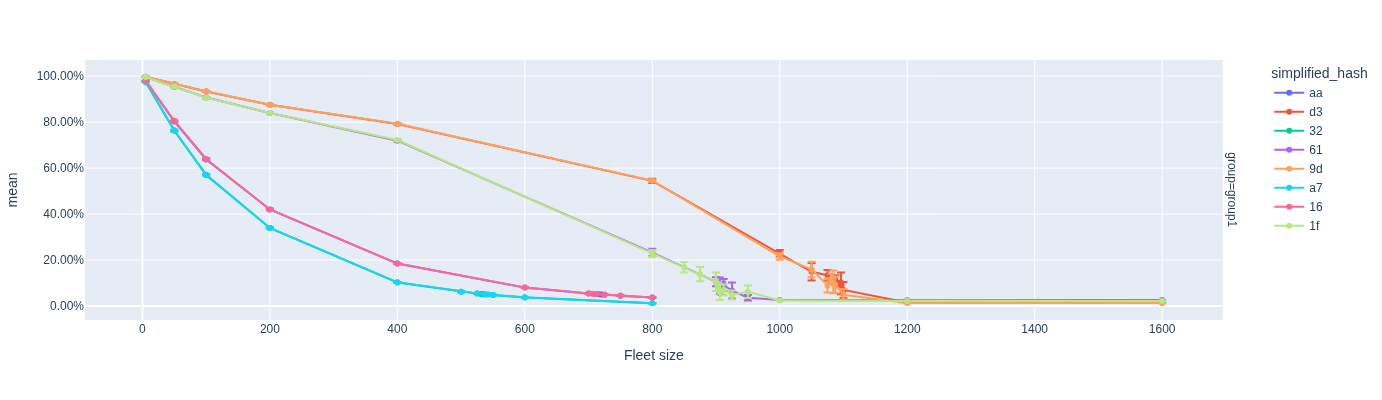

In [5]:
if len(df) > 0:
    df = df.sort_values("fleet_size")
    fig = px.line(df, x="fleet_size", color="simplified_hash", y="mean", error_y="std",
                  facet_row="group", height=400, markers=True, hover_data=["count"],
                  labels=dict(fleet_size="Fleet size", rejection_rate="Rejection rate"))
    fig.update_yaxes(tickformat=".2%")
    # fig.update_layout(showlegend=False)
    fig.show()
else:
    print("No data")

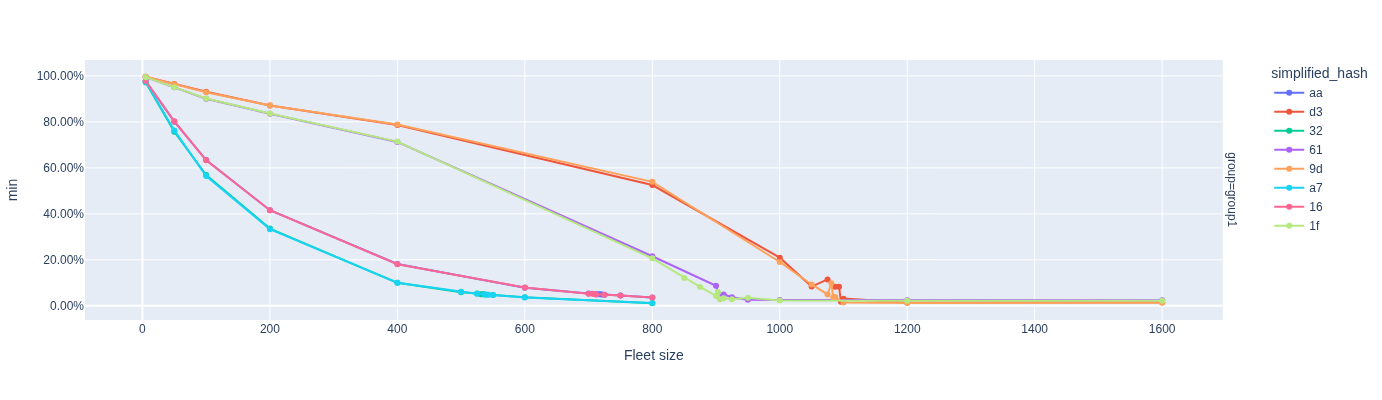

In [7]:
if len(df) > 0:
    df = df.sort_values("fleet_size")
    fig = px.line(df, x="fleet_size", color="simplified_hash", y="min", 
                  facet_row="group", height=400, markers=True, hover_data=["count"],
                  labels=dict(fleet_size="Fleet size", rejection_rate="Rejection rate"))
    fig.update_yaxes(tickformat=".2%")
    # fig.update_layout(showlegend=False)
    fig.show()
else:
    print("No data")